In [1]:
import numpy as np
w1 = np.array([2, 2])
b1 = 5
w2 = np.array([20, 20])
b2 = 3
norm1 = np.linalg.norm(w1)
norm2 = np.linalg.norm(w2)
margin1 = 1 / norm1
margin2 = 1 / norm2
error1 = 0.5 * norm1**2
error2 = 0.5 * norm2**2
print("Classifier 1")
print("Norm =", norm1)
print("Margin =", margin1)
print("Error =", error1)
print("\nClassifier 2")
print("Norm =", norm2)
print("Margin =", margin2)
print("Error =", error2)
if error1 < error2:
    print("\nClassifier 1 is selected")
else:
    print("\nClassifier 2 is selected")




Classifier 1
Norm = 2.8284271247461903
Margin = 0.35355339059327373
Error = 4.000000000000001

Classifier 2
Norm = 28.284271247461902
Margin = 0.035355339059327376
Error = 400.00000000000006

Classifier 1 is selected


Weight = [0.8 0.4]
Bias = -1.8000000000000003


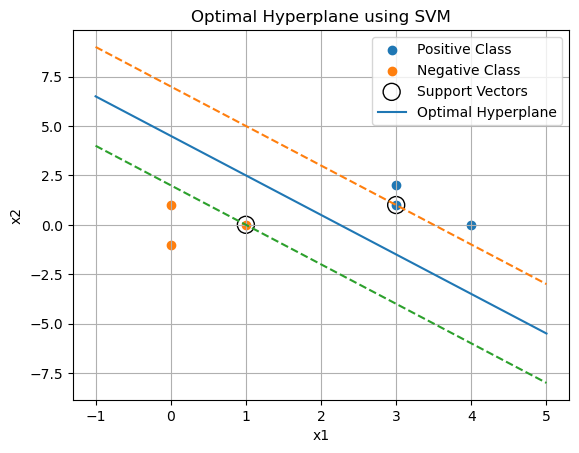

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
positive = np.array([
    [3, 1],
    [3, 2],
    [4, 0]
])
negative = np.array([
    [1, 0],
    [0, 1],
    [0, -1]
])
X = np.vstack((positive, negative))
y = np.array([1, 1, 1, -1, -1, -1])
model = SVC(kernel='linear', C=1000)
model.fit(X, y)
w = model.coef_[0]
b = model.intercept_[0]
print("Weight =", w)
print("Bias =", b)
x = np.linspace(-1, 5, 200)
y_hyperplane = -(w[0] * x + b) / w[1]
y_margin1 = -(w[0] * x + b - 1) / w[1]
y_margin2 = -(w[0] * x + b + 1) / w[1]
plt.scatter(positive[:, 0], positive[:, 1],
            label="Positive Class")
plt.scatter(negative[:, 0], negative[:, 1],
            label="Negative Class")
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=150, facecolors='none',
            edgecolors='black',
            label="Support Vectors")
plt.plot(x, y_hyperplane,
         label="Optimal Hyperplane")
plt.plot(x, y_margin1, '--')
plt.plot(x, y_margin2, '--')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Optimal Hyperplane using SVM")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
X = np.array([
    [3, 1],
    [3, 2],
    [4, 0],
    [1, 0],
    [0, 1],
    [0, -1]
])
y = np.array([
    1,
    1,
    1,
    -1,
    -1,
    -1
])
C_values = [0.01, 0.1, 1, 10, 100, 1000]
best_accuracy = 0
best_C = None
best_model = None
for C in C_values:

    model = SVC(
        kernel="linear",
        C=C
    )
    model.fit(X, y)
    accuracy = model.score(X, y)
    print("C =", C, "Accuracy =", accuracy)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_C = C
        best_model = model
print("\nBest C =", best_C)
print("Best Accuracy =", best_accuracy)
w = best_model.coef_[0]
b = best_model.intercept_[0]
print("\nw1 =", w[0])
print("w2 =", w[1])
print("b  =", b)--
print("\nOptimal Hyperplane:")
print(
    w[0],
    "x1 +",
    w[1],
    "x2 +",
    b,
    "= 0"
)
print("\nSupport Vectors:")
print(best_model.support_vectors_)
margin = 2 / np.linalg.norm(w)
print("\nMargin =", margin)
plt.figure(figsize=(8, 6))
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='o',
    label="Positive"
)
plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    marker='x',
    label="Negative"
)
plt.scatter(
    best_model.support_vectors_[:, 0],
    best_model.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    label="Support Vectors"
)
x1 = np.linspace(-1, 5, 100)
x2 = -(w[0] * x1 + b) / w[1]
plt.plot(
    x1,
    x2,
    label="Optimal Hyperplane"
)
x2_positive = -(w[0] * x1 + b - 1) / w[1]
plt.plot(
    x1,
    x2_positive,
    '--',
    label="Positive Margin"
)
x2_negative = -(w[0] * x1 + b + 1) / w[1]
plt.plot(
    x1,
    x2_negative,
    '--',
    label="Negative Margin"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVM Hyperplane Fine-Tuning")
plt.legend()
plt.grid()
plt.show()